📂 Loading data for SHAP Analysis from: C:\Users\user\fraud-detection\data\processed\cleaned_fraud_data.csv
🌲 Fitting Ensemble Model for SHAP evaluation...
📊 Generating Built-In Feature Importance Baseline...


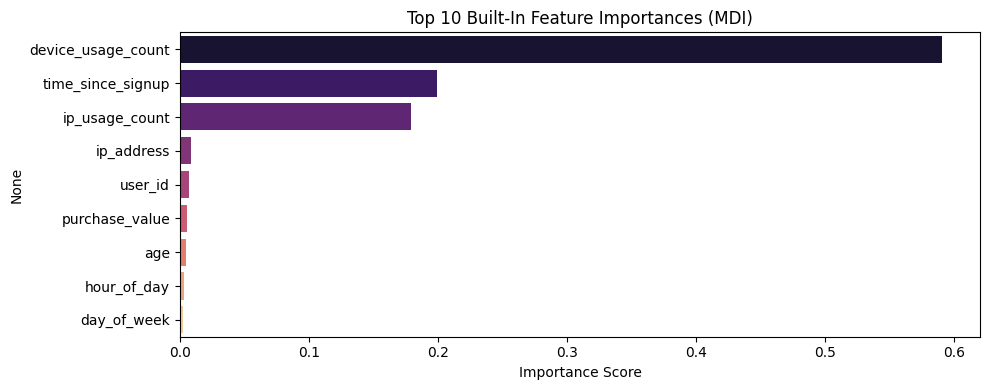

🔮 Calculating SHAP values using TreeExplainer...
📈 Rendering Global SHAP Summary Plot...


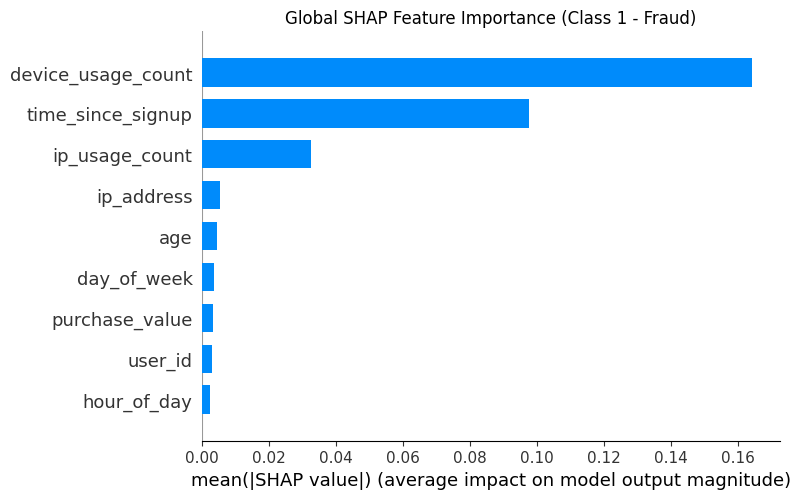

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load Data directly from the processed directory
csv_path = r"C:\Users\user\fraud-detection\data\processed\cleaned_fraud_data.csv"
print(f"📂 Loading data for SHAP Analysis from: {csv_path}")
df = pd.read_csv(csv_path)

# Separate features and target
X = df.drop(columns=['class']) if 'class' in df.columns else df.drop(columns=[df.columns[-1]])
y = df['class'] if 'class' in df.columns else df[df.columns[-1]]
X = X.select_dtypes(include=[np.number]) # Filter down to numeric columns

# Create Stratified Train/Test Splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Re-train the optimal Random Forest model
print("🌲 Fitting Ensemble Model for SHAP evaluation...")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Task 3 Baseline: Built-In Feature Importance
print("📊 Generating Built-In Feature Importance Baseline...")
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, hue=importances.head(10).index, palette="magma", legend=False)
plt.title("Top 10 Built-In Feature Importances (MDI)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 4. Initialize SHAP TreeExplainer
print("🔮 Calculating SHAP values using TreeExplainer...")
explainer = shap.TreeExplainer(rf_model)
X_sample = X_test.sample(200, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Generate SHAP Global Summary Plot
print("📈 Rendering Global SHAP Summary Plot...")
plt.figure(figsize=(10, 5))

# Handle SHAP output structures safely across different package versions
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
elif len(shap_values.shape) == 3: # Format for newer shap versions on multi-class output
    shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)

plt.title("Global SHAP Feature Importance (Class 1 - Fraud)")
plt.tight_layout()
plt.show()

🔍 Searching for distinct fraud prediction archetypes...



🎯 [True Positive] Row found at sample offset: 2. Rendering Force Plot...


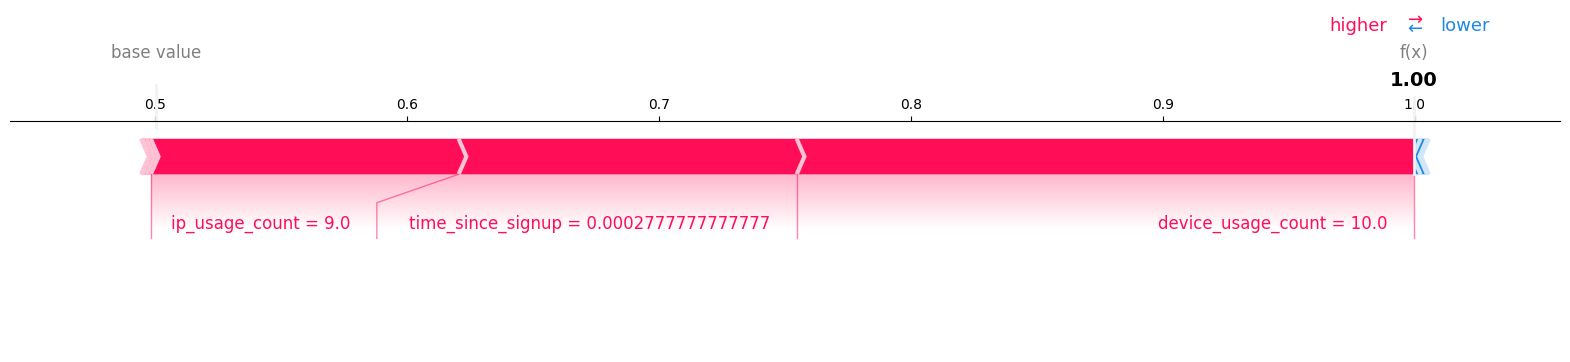


🚨 [False Positive] Row found at sample offset: 7. Rendering Force Plot...


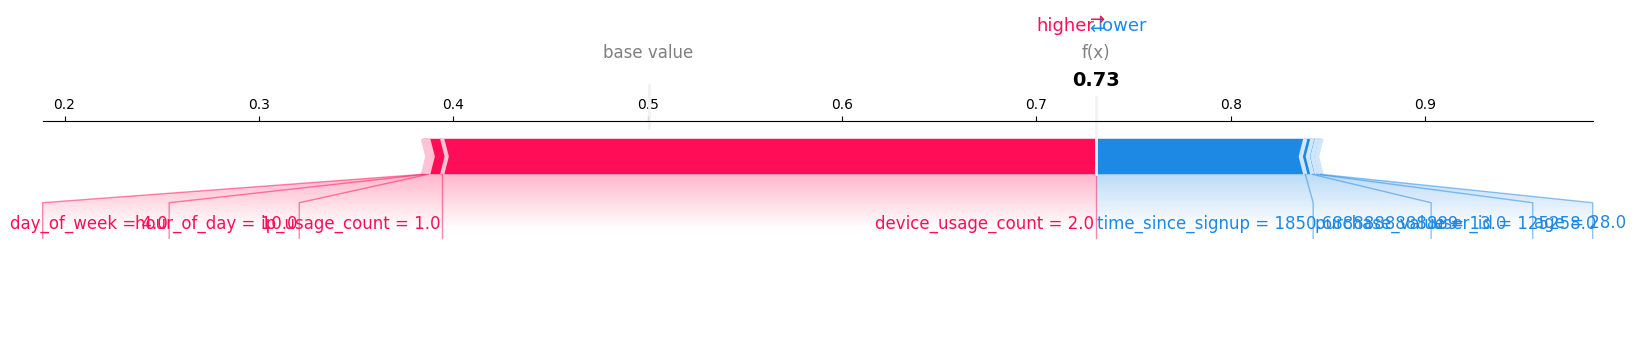


🕵️‍♂️ [False Negative] Row found at sample offset: 6. Rendering Force Plot...


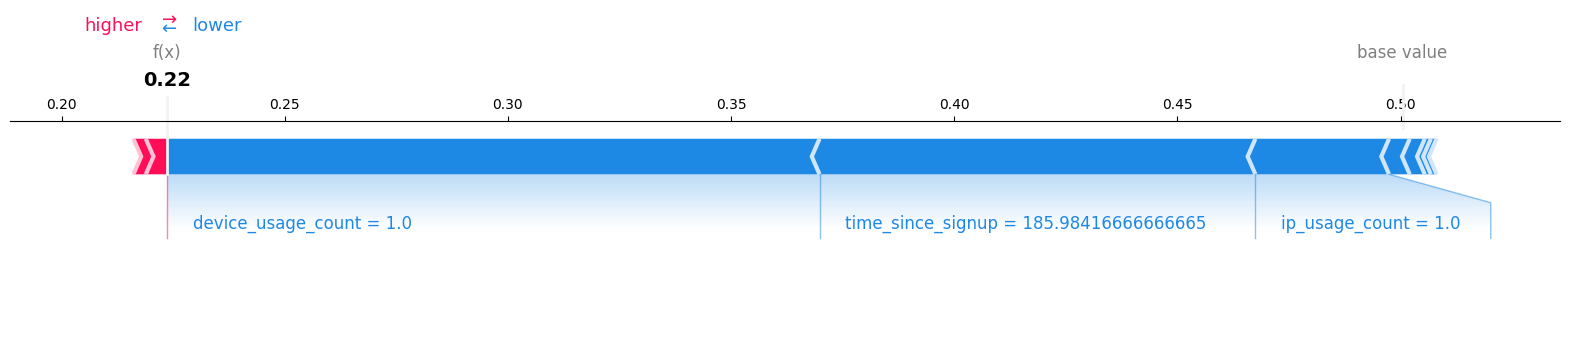

In [5]:
# 5. Extract Individual Predictions for Forced Local Explanation Plots
print("🔍 Searching for distinct fraud prediction archetypes...")

# Generate probability predictions on our test subset sample
preds_prob = rf_model.predict_proba(X_sample)[:, 1]
preds_binary = rf_model.predict(X_sample)
actuals = y_test.loc[X_sample.index].values

# Map out indices inside our 200-row sample matrix
tp_idx = np.where((preds_binary == 1) & (actuals == 1))[0]
fp_idx = np.where((preds_binary == 1) & (actuals == 0))[0]
fn_idx = np.where((preds_binary == 0) & (actuals == 1))[0]

# Initialize SHAP interactive plotting JavaScript
shap.initjs()

# Helper function to extract individual array objects depending on SHAP version
def get_local_shap(shap_obj, idx):
    if isinstance(shap_obj, list):
        return shap_obj[1][idx]
    elif len(shap_obj.shape) == 3:
        return shap_obj[idx, :, 1]
    return shap_obj[idx]

# Extract expected base value safely
base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

# --- 1. TRUE POSITIVE PLOT ---
if len(tp_idx) > 0:
    print(f"\n🎯 [True Positive] Row found at sample offset: {tp_idx[0]}. Rendering Force Plot...")
    # 🔥 FIX: Remove plt.figure() and let shap draw directly to the notebook cell using matplotlib=True
    shap.force_plot(
        base_value, 
        get_local_shap(shap_values, tp_idx[0]), 
        X_sample.iloc[tp_idx[0]], 
        matplotlib=True,
        show=True
    )
else:
    print("\n⚠️ No True Positive found in this small 200-row sample window.")

# --- 2. FALSE POSITIVE PLOT ---
if len(fp_idx) > 0:
    print(f"\n🚨 [False Positive] Row found at sample offset: {fp_idx[0]}. Rendering Force Plot...")
    shap.force_plot(
        base_value, 
        get_local_shap(shap_values, fp_idx[0]), 
        X_sample.iloc[fp_idx[0]], 
        matplotlib=True,
        show=True
    )
else:
    print("\n⚠️ No False Positive found in this small 200-row sample window.")

# --- 3. FALSE NEGATIVE PLOT ---
if len(fn_idx) > 0:
    print(f"\n🕵️‍♂️ [False Negative] Row found at sample offset: {fn_idx[0]}. Rendering Force Plot...")
    shap.force_plot(
        base_value, 
        get_local_shap(shap_values, fn_idx[0]), 
        X_sample.iloc[fn_idx[0]], 
        matplotlib=True,
        show=True
    )
else:
    print("\n⚠️ No False Negative found in this small 200-row sample window.")